# Week 5 Capstone: verified-evidence workflow

The original Week 4 archive is unavailable and its saved outputs are corrupted, but the exact Week 3 and Week 4 query/output pairs are independently recoverable from the later verified Week 9 record. This notebook reconciles all 207 verified observations and generates reproducible Week 5 proposals without inventing data.

## Errors found and corrected

1. `/content/week_4_data.zip`, `Week_4_inputs.txt`, and `Week_4_outputs.txt` do not exist in the repository.
2. All `/content/...` paths are Colab-specific and fail locally.
3. The input file was parsed twice: pandas reported 264 values while regex reported 143; outputs similarly changed from 32 to 68. Neither result was validated.
4. Flattening mixed text and slicing by dimension caused cross-function shifts and object arrays; saved output even prints malformed array strings.
5. The inherited archive contains impossible values (`64` shared by unrelated functions) and loses confirmed optima, so it is not evidence.
6. The empty `week5_queries.txt` cannot recover the original submissions, but exact Week 3–4 pairs are preserved in the later verified Week 9 record and are reconciled here with explicit provenance.
7. Generated data was written to `/content` and depended on cell order. Data is reconstructed in memory by function.
8. GP randomness was uncontrolled, duplicate rounded proposals were unchecked, and model diagnostics were discarded.
9. Plots showed only raw trends. Running-best, every feature relationship, round markers, uncertainty, acquisition, and exploration distance are now plotted.
10. The performance table incorrectly called corrupted data confirmed. Evidence status is now explicit.

In [1]:
from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel

FUNCTIONS=tuple(range(1,9)); DIMS={1:2,2:2,3:3,4:4,5:4,6:5,7:6,8:8}
METHOD={1:'UCB',2:'UCB',3:'UCB',4:'UCB',5:'Expected Improvement',6:'UCB',7:'UCB',8:'UCB'}
KAPPA={1:5.,2:5.,3:4.,4:4.,6:4.,7:3.,8:2.}
QUERIES={1:[[.375440,.950714],[.536429,.835362],[.614168,.334143],[.872626,.321598]],2:[[.375440,.950714],[.978752,.932731],[.000006,.334143],[.197553,.808683]],3:[[.444444,.666666,.333333],[.657452,.998464,.817253],[.670026,.057881,.658241],[.650132,.218327,.110542]],4:[[.555555,.444444,.222222,.111111],[.006280,.281840,.932013,.960202],[.394519,.361122,.256803,.461856],[.715715,.504442,.275065,.552962]],5:[[.224189,.846480,.879484,.878515],[.255841,.841692,.888984,.860260],[.255842,.841692,.888985,.860266],[0.,0.,0.,0.]],6:[[.728186,.154693,.732552,.693997,.564013],[.433654,.486678,.282753,.972905,.323321],[.495070,.097152,.672921,.000007,.351268],[.973181,.022807,.714484,.145453,.974790]],7:[[.045091,.528666,.329265,.105350,.434667,.641164],[.243848,.900100,.696978,.193630,.374149,.826324],[.143585,.302559,.571101,.194533,.395561,.815792],[.045103,.016167,.773003,.156031,.147073,.616114]],8:[[.273673,.260400,.073937,.078562,.862321,.230729,.106880,.352588],[.163160,.184786,.152644,.083802,.999322,.544113,.184124,.123846],[.088894,.525132,.030986,.992538,.870819,.217060,.011239,.447691],[.356502,.157574,.172997,.610561,.106477,.260297,.411421,.904740]]}
OUTPUTS={1:[-1.560646704467778e-117,1.674933466363685e-36,-1.0755942664604116e-32,-2.4666412561217706e-107],2:[-.03182956281754251,.022666631114895516,.04868370128566149,.038774938576018964],3:[-.04090761844901528,-.08987474979637637,-.18323876643005035,-.08251349582236739],4:[-8.727516493155957,-31.73535839431216,-1.9810750402526334,-9.312811809021998],5:[1088.8535114737463,1035.6341457754475,1035.6647479285914,163.1225],6:[-1.1520351120911565,-.8782405650300305,-1.339542402620705,-2.4375082517089726],7:[1.0510148516295004,.308765180253091,2.149905456773691,1.2087334449610816],8:[9.8157087929671,9.9399041910574,8.9636037557014,9.2540644925525]}
def find_root(start=None):
    p=Path.cwd() if start is None else Path(start).resolve()
    for c in (p,*p.parents):
        if (c/'Week_01').is_dir() and (c/'Week_05').is_dir(): return c
    raise FileNotFoundError('Repository root not found.')
ROOT=find_root(); plt.style.use('seaborn-v0_8-whitegrid'); print(f'Repository root: {ROOT}')

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def validate(fn,X,y):
    if X.ndim!=2 or X.shape[1]!=DIMS[fn]: raise ValueError(f'F{fn}: expected (*,{DIMS[fn]}), got {X.shape}.')
    if y.ndim!=1 or len(X)!=len(y) or not len(y): raise ValueError(f'F{fn}: invalid observation counts.')
    if not np.isfinite(X).all() or not np.isfinite(y).all(): raise ValueError(f'F{fn}: non-finite data.')
    if np.any((X<0)|(X>1)): raise ValueError(f'F{fn}: input outside [0,1].')
def load_confirmed(fn):
    folder=ROOT/'Week_01'/f'Function_{fn:02d}'/'03_Data'; a,b=folder/'initial_inputs.npy',folder/'initial_outputs.npy'
    if not a.is_file() or not b.is_file(): raise FileNotFoundError(f'F{fn}: starter data missing.')
    X=np.asarray(np.load(a),float); y=np.asarray(np.load(b),float).reshape(-1); validate(fn,X,y)
    for round_number,(q,v) in enumerate(zip(QUERIES[fn],OUTPUTS[fn]),1):
        q=np.asarray(q,float)
        if q.shape!=(DIMS[fn],): raise ValueError(f'F{fn}, round {round_number}: wrong dimension.')
        X=np.vstack((X,q)); y=np.append(y,v)
    validate(fn,X,y); return X,y

## Function-by-function review

The newest verified value is the recovered Week 4 return. Weeks 3 and 4 are reconciled from exact function-grouped pairs preserved in the later Week 9 record. Percentiles permit comparison without mixing incompatible objective scales.

In [3]:
def summarize(fn):
    X,y=load_confirmed(fn); previous=y[:-1]; best=int(np.argmax(y))
    return {'Function':f'F{fn}','Method':METHOD[fn],'Dimensions':DIMS[fn],'Verified observations':len(y),'Previous best':float(np.max(previous)),'Week 4 return':float(y[-1]),'Verified best':float(y[best]),'Week 4 improvement':float(np.max(y)-np.max(previous)),'Week 4 percentile':100*float(np.mean(previous<=y[-1])),'Best query':best+1,'Best input':X[best].tolist(),'Provenance':'Weeks 3–4 exact pairs recovered from Week 9 record'}
performance=pd.DataFrame([summarize(i) for i in FUNCTIONS]); performance


,Function,Method,Dimensions,Verified observations,Previous best,Week 4 return,Verified best,Week 4 improvement,Week 4 percentile,Best query,Best input,Provenance
0,F1,UCB,2,14,7.710875e-16,-2.466641e-107,7.710875e-16,0.0,30.769231,3,"[0.7310236309563586, 0.7329998764152272]",Weeks 3–4 exact pairs recovered from Week 9 re...
1,F2,UCB,2,14,6.112052e-01,3.877494e-02,6.112052e-01,0.0,46.153846,10,"[0.7026365569244406, 0.9265641975455574]",Weeks 3–4 exact pairs recovered from Week 9 re...
2,F3,UCB,3,19,-3.483531e-02,-8.251350e-02,-3.483531e-02,0.0,66.666667,4,"[0.49258141463713434, 0.6115931882759961, 0.34...",Weeks 3–4 exact pairs recovered from Week 9 re...
3,F4,UCB,4,34,-1.981075e+00,-9.312812e+00,-1.981075e+00,0.0,84.848485,33,"[0.394519, 0.361122, 0.256803, 0.461856]",Weeks 3–4 exact pairs recovered from Week 9 re...
4,F5,Expected Improvement,4,24,1.088860e+03,1.631225e+02,1.088860e+03,0.0,65.217391,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",Weeks 3–4 exact pairs recovered from Week 9 re...
5,F6,UCB,5,24,-7.142649e-01,-2.437508e+00,-7.142649e-01,0.0,4.347826,1,"[0.7281861047460138, 0.1546925696237983, 0.732...",Weeks 3–4 exact pairs recovered from Week 9 re...
6,F7,UCB,6,34,2.149905e+00,1.208733e+00,2.149905e+00,0.0,93.939394,33,"[0.143585, 0.302559, 0.571101, 0.194533, 0.395...",Weeks 3–4 exact pairs recovered from Week 9 re...
7,F8,UCB,8,44,9.939904e+00,9.254064e+00,9.939904e+00,0.0,90.697674,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993...",Weeks 3–4 exact pairs recovered from Week 9 re...


In [4]:
for r in performance.to_dict('records'):
    status='IMPROVED' if r['Week 4 improvement']>0 else 'NO NEW BEST'
    print(f"{r['Function']} — {r['Method']} — {status}")
    print(f"  observations={r['Verified observations']}, dimensions={r['Dimensions']}")
    print(f"  previous={r['Previous best']:.12g}, Week 4={r['Week 4 return']:.12g}, best={r['Verified best']:.12g}")
    print(f"  provenance: {r['Provenance']}")

F1 — UCB — NO NEW BEST
  observations=14, dimensions=2
  previous=7.7108751145e-16, Week 4=-2.46664125612e-107, best=7.7108751145e-16
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
F2 — UCB — NO NEW BEST
  observations=14, dimensions=2
  previous=0.611205215761, Week 4=0.038774938576, best=0.611205215761
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
F3 — UCB — NO NEW BEST
  observations=19, dimensions=3
  previous=-0.0348353133501, Week 4=-0.0825134958224, best=-0.0348353133501
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
F4 — UCB — NO NEW BEST
  observations=34, dimensions=4
  previous=-1.98107504025, Week 4=-9.31281180902, best=-1.98107504025
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
F5 — Expected Improvement — NO NEW BEST
  observations=24, dimensions=4
  previous=1088.8596182, Week 4=163.1225, best=1088.8596182
  provenance: Weeks 3–4 exact pairs recovered from Week 9 record
F6 — UCB — NO NEW BEST
  obs

## Reproducible Week 5 proposals

The intended mixed strategy is retained: UCB for F1–F4/F6–F8 and Expected Improvement for F5. Proposals use only verified evidence and are checked after six-decimal rounding.

In [5]:
def expected_improvement(mean,std,best):
    safe=np.maximum(std,1e-12); delta=mean-best; z=delta/safe
    return delta*norm.cdf(z)+safe*norm.pdf(z)
def propose(fn,X,y,rng,n=5000):
    d=X.shape[1]; base=RBF(np.ones(d),(1e-2,1e2)) if fn in (1,5) else Matern(np.ones(d),(1e-2,1e2),nu=2.5)
    kernel=ConstantKernel(1.,(1e-3,1e3))*base+WhiteKernel(1e-5,(1e-10,1e1))
    gp=GaussianProcessRegressor(kernel=kernel,normalize_y=True,n_restarts_optimizer=3,random_state=42)
    with warnings.catch_warnings(): warnings.simplefilter('ignore',ConvergenceWarning); gp.fit(X,y)
    candidates=rng.uniform(0,1,(n,d)); mean,std=gp.predict(candidates,return_std=True)
    acquisition=expected_improvement(mean,std,np.max(y)) if fn==5 else mean+KAPPA[fn]*std
    for idx in np.argsort(acquisition)[::-1]:
        q=np.round(candidates[idx],6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)):
            return {'query':q,'kernel':str(gp.kernel_),'std':float(std[idx]),'acquisition':float(acquisition[idx]),'mean':float(mean[idx])}
    raise RuntimeError('No distinct proposal.')

In [6]:
week_5_queries,rows={},[]
for fn in FUNCTIONS:
    X,y=load_confirmed(fn); result=propose(fn,X,y,np.random.default_rng(500+fn)); q=result['query']; week_5_queries[fn]=q
    rows.append({'Function':f'F{fn}','Method':METHOD[fn],'Kappa':KAPPA.get(fn,np.nan),'Proposed query':q.tolist(),'Fitted kernel':result['kernel'],'Predictive mean':result['mean'],'Predictive std':result['std'],'Acquisition score':result['acquisition'],'Distance from best':float(np.linalg.norm(q-X[int(np.argmax(y))]))})
proposal_summary=pd.DataFrame(rows); proposal_summary

,Function,Method,Kappa,Proposed query,Fitted kernel,Predictive mean,Predictive std,Acquisition score,Distance from best
0,F1,UCB,5.0,"[0.684891, 0.506817]","1.05**2 * RBF(length_scale=[100, 0.0312]) + Wh...",-0.000242,0.000975,0.004633,0.230840
1,F2,UCB,5.0,"[0.759814, 0.068564]","0.934**2 * Matern(length_scale=[0.0573, 100], ...",0.366527,0.161596,1.174509,0.859903
2,F3,UCB,4.0,"[0.705864, 0.101333, 0.003366]","1.91**2 * Matern(length_scale=[100, 1.75, 0.14...",-0.039875,0.081211,0.284971,0.647531
3,F4,UCB,4.0,"[0.432478, 0.431203, 0.425623, 0.423561]","4.73**2 * Matern(length_scale=[2, 1.97, 2, 2.0...",-1.182720,0.473525,0.711381,0.190575
4,F5,Expected Improvement,NaN,"[0.888613, 0.327812, 0.99442, 0.994792]","2.04**2 * RBF(length_scale=[15.7, 5.47, 0.528,...",1809.352089,77.125721,720.492471,0.858607
5,F6,UCB,4.0,"[0.239216, 0.002533, 0.976443, 0.897726, 0.221...","1.59**2 * Matern(length_scale=[0.471, 1.2, 1.2...",-0.793639,0.390519,0.768438,0.624882
6,F7,UCB,3.0,"[0.05284, 0.305744, 0.978924, 0.162682, 0.2921...","1.1**2 * Matern(length_scale=[1.04, 0.483, 100...",2.115649,0.225502,2.792156,0.468188
7,F8,UCB,2.0,"[0.074234, 0.087874, 0.175131, 0.200928, 0.987...","6.72**2 * Matern(length_scale=[4.58, 7.13, 3.7...",9.961830,0.055365,10.072559,0.643135


## Complete Matplotlib diagnostics

Red diamonds mark the latest confirmed observation and gold stars the confirmed optimum. Feature panels are coloured by query order.

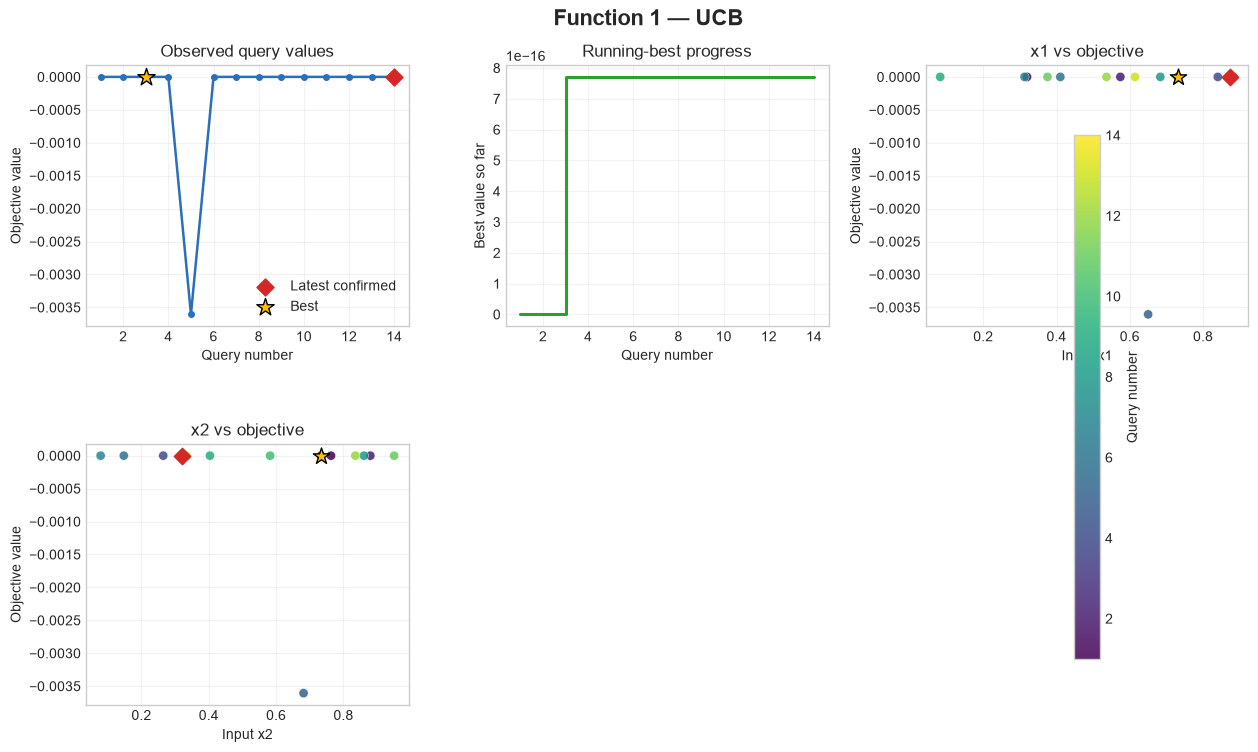

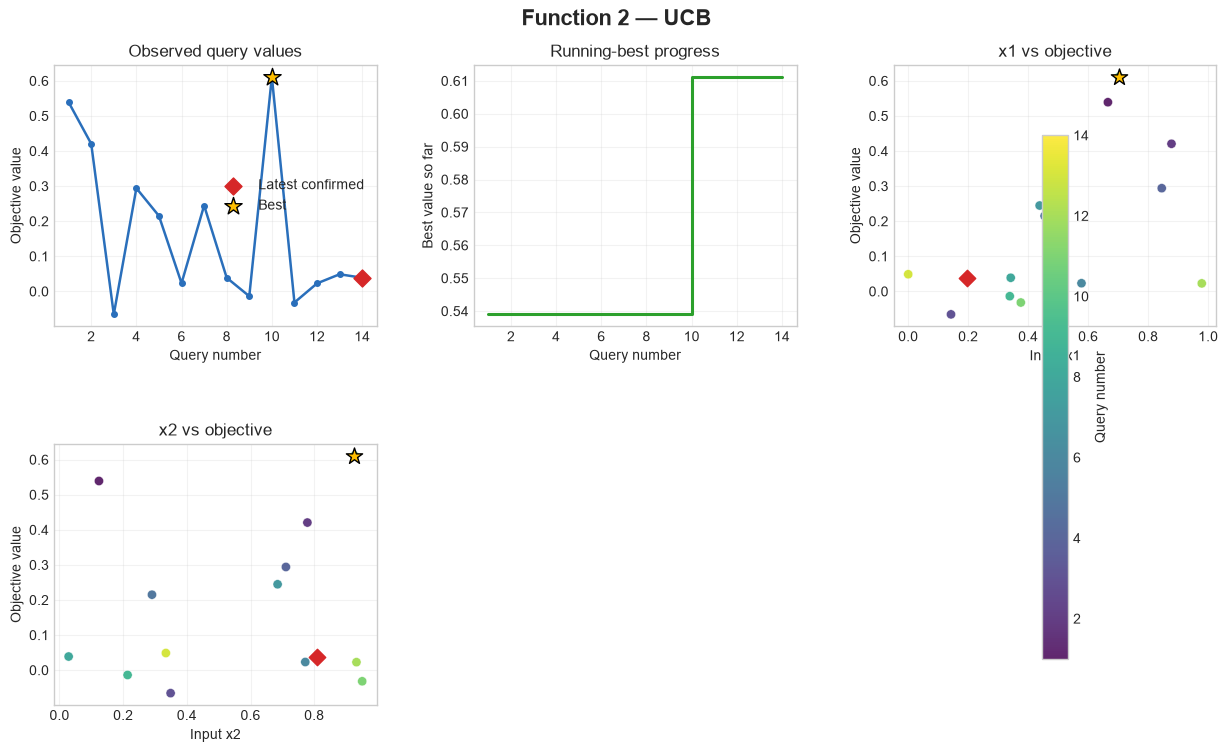

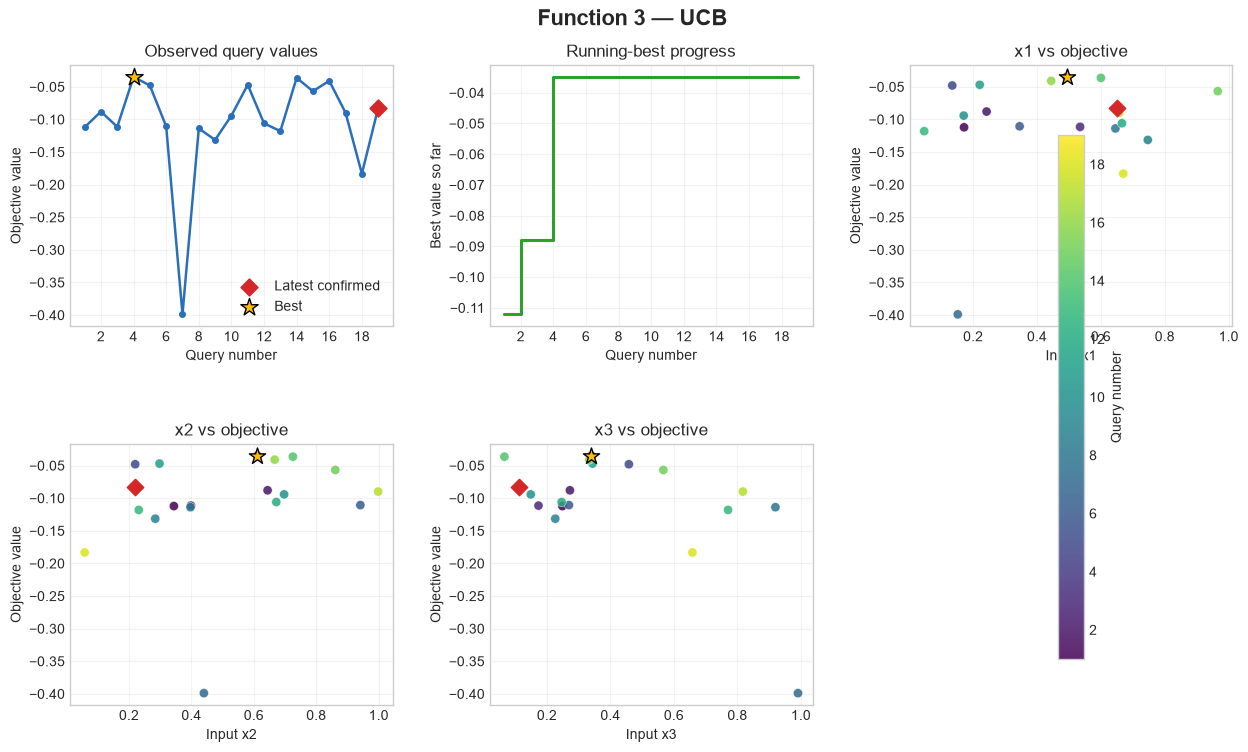

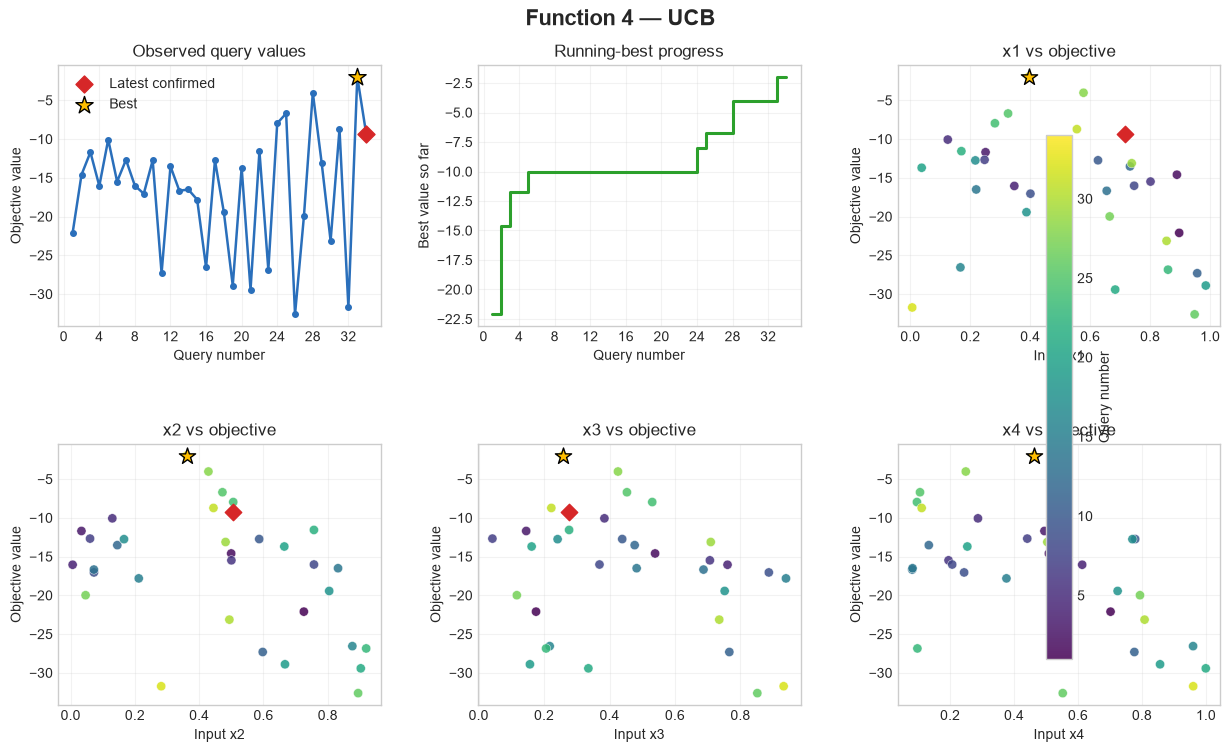

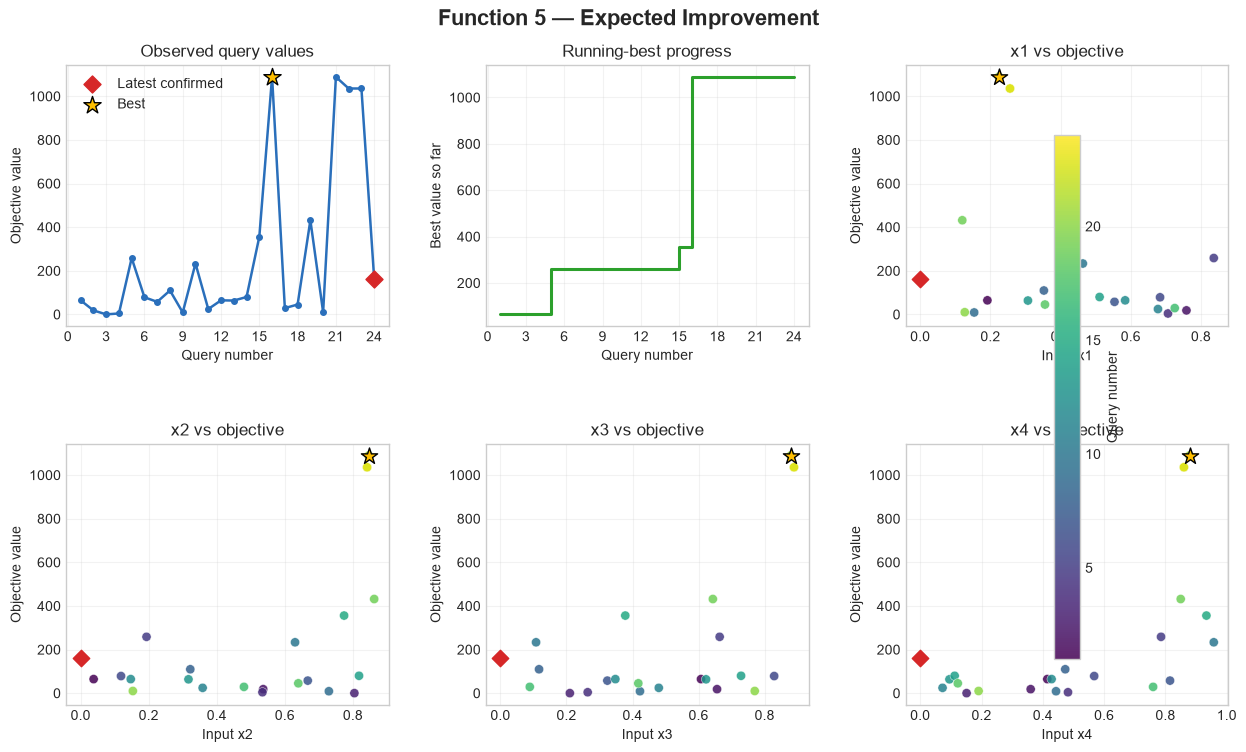

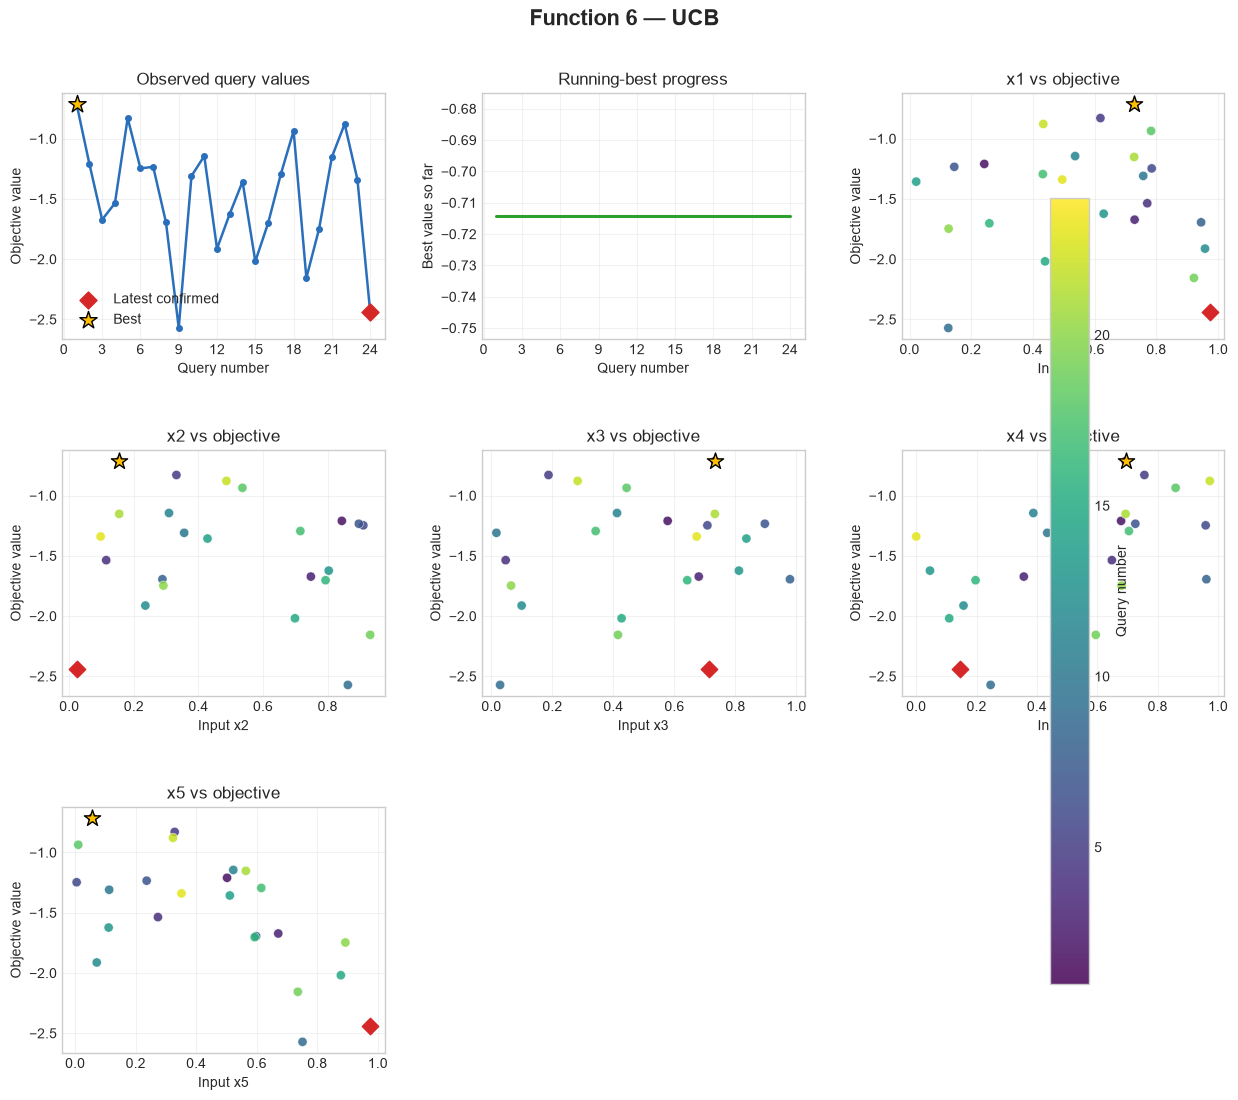

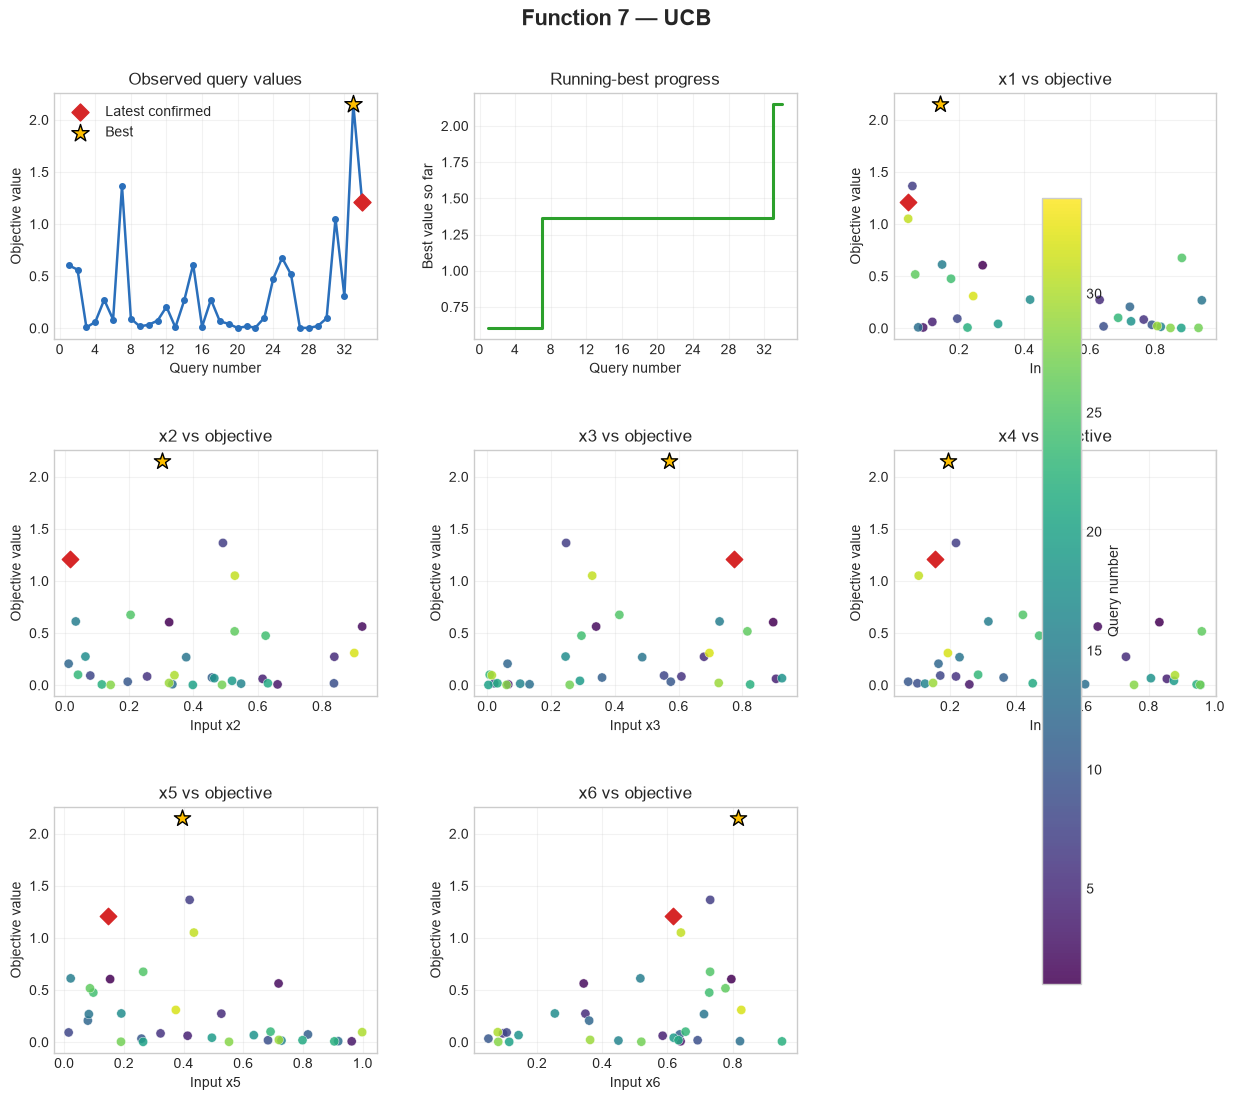

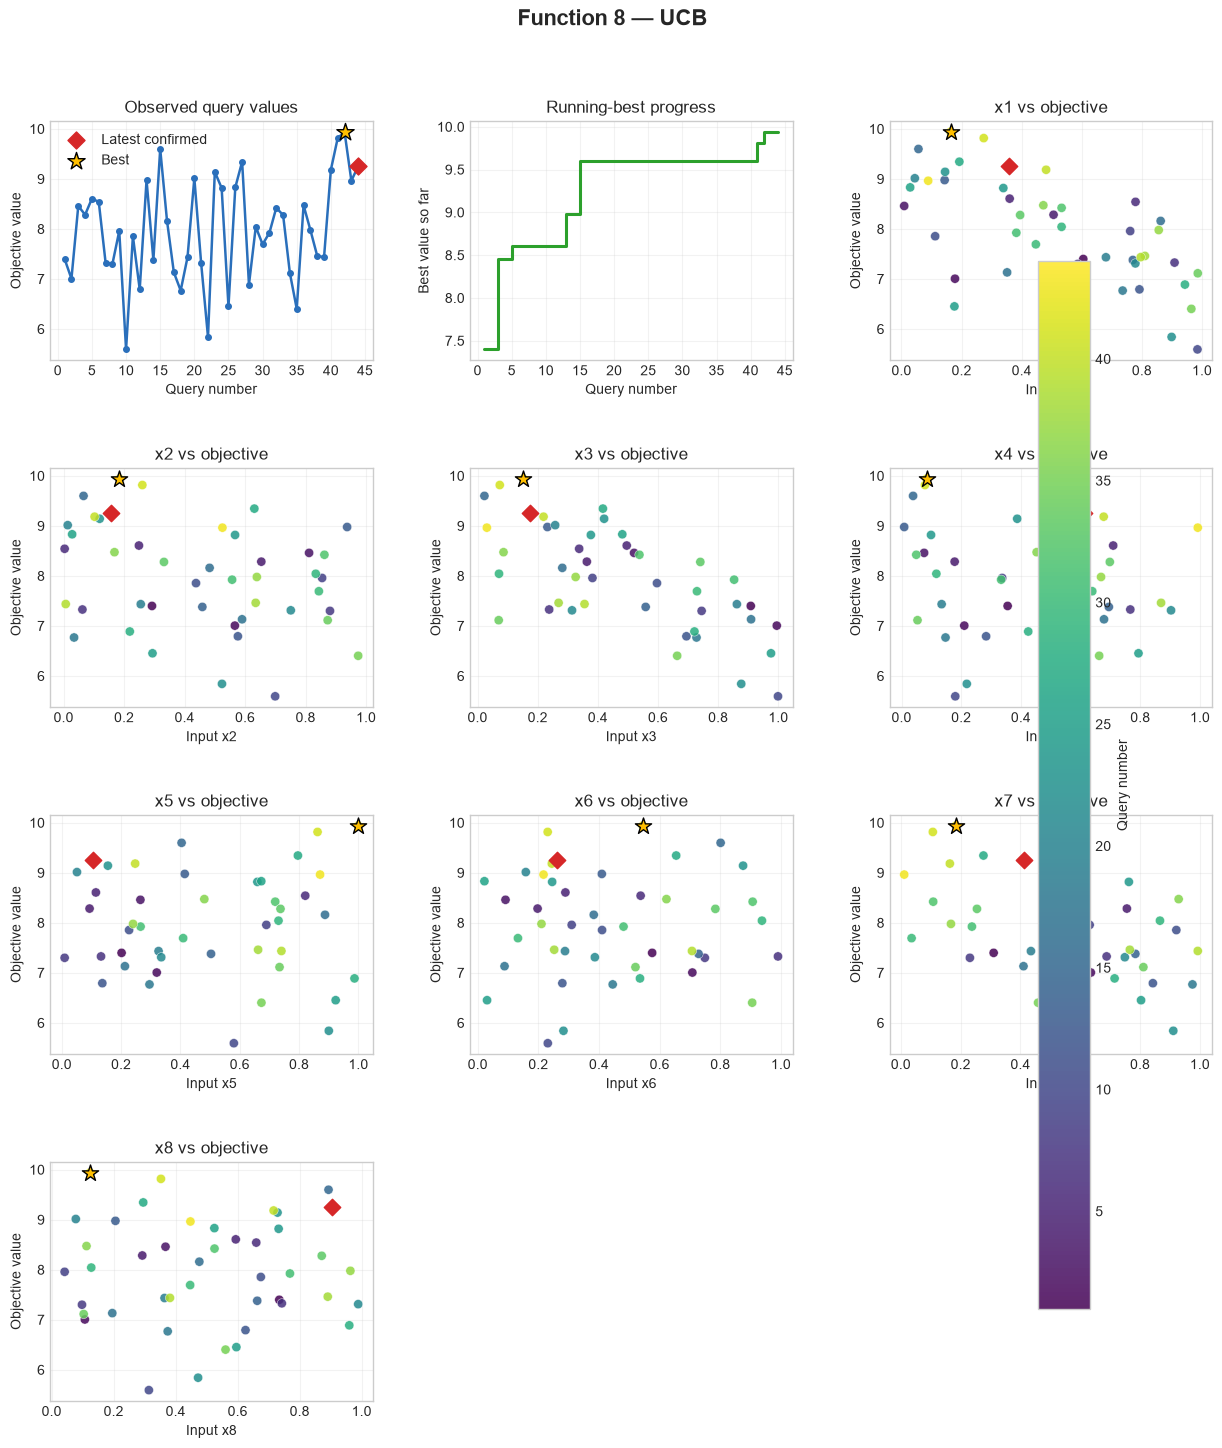

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(fn):
    X,y=load_confirmed(fn); q=np.arange(1,len(y)+1); best=int(np.argmax(y)); panels=X.shape[1]+2; cols=3; nrows=math.ceil(panels/cols)
    fig,axes=plt.subplots(nrows,cols,figsize=(15,4*nrows),squeeze=False); axes=axes.ravel()
    axes[0].plot(q,y,color='#2a6fbb',marker='o',lw=1.8,ms=4); axes[0].scatter(q[-1],y[-1],marker='D',color='#d62728',s=75,zorder=4,label='Latest confirmed'); axes[0].scatter(q[best],y[best],marker='*',color='#ffbf00',edgecolor='black',s=170,zorder=5,label='Best')
    axes[0].set(xlabel='Query number',ylabel='Objective value',title='Observed query values'); axes[0].legend(); axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].step(q,np.maximum.accumulate(y),where='post',color='#2ca02c',lw=2.2); axes[1].set(xlabel='Query number',ylabel='Best value so far',title='Running-best progress'); axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    colour=None
    for col,axis in enumerate(axes[2:2+X.shape[1]]):
        colour=axis.scatter(X[:,col],y,c=q,cmap='viridis',s=44,alpha=.85,edgecolor='white',lw=.35); axis.scatter(X[-1,col],y[-1],marker='D',color='#d62728',s=70,zorder=4); axis.scatter(X[best,col],y[best],marker='*',color='#ffbf00',edgecolor='black',s=150,zorder=5); axis.set(xlabel=f'Input x{col+1}',ylabel='Objective value',title=f'x{col+1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True,alpha=.25)
    fig.colorbar(colour,ax=axes[2:2+X.shape[1]].tolist(),label='Query number',shrink=.85); fig.suptitle(f'Function {fn} — {METHOD[fn]}',fontsize=16,fontweight='bold'); fig.subplots_adjust(top=.91,hspace=.45,wspace=.30); return fig
figures=[plot_function(i) for i in FUNCTIONS]; plt.show(); print(f'Rendered {len(figures)} function diagnostic figures.')

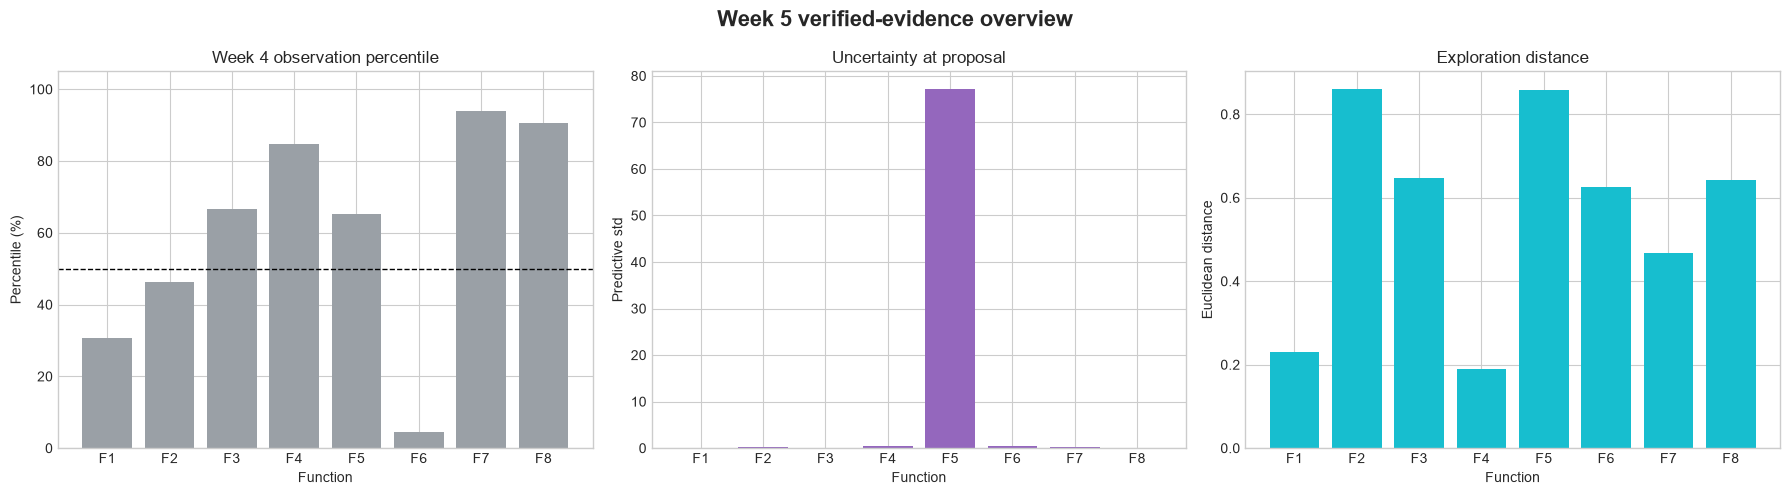

In [8]:
fig,axes=plt.subplots(1,3,figsize=(18,5)); colours=np.where(performance['Week 4 improvement']>0,'#2ca02c','#9aa0a6')
axes[0].bar(performance['Function'],performance['Week 4 percentile'],color=colours); axes[0].axhline(50,color='black',ls='--',lw=1); axes[0].set(title='Week 4 observation percentile',xlabel='Function',ylabel='Percentile (%)',ylim=(0,105))
axes[1].bar(proposal_summary['Function'],proposal_summary['Predictive std'],color='#9467bd'); axes[1].set(title='Uncertainty at proposal',xlabel='Function',ylabel='Predictive std')
axes[2].bar(proposal_summary['Function'],proposal_summary['Distance from best'],color='#17becf'); axes[2].set(title='Exploration distance',xlabel='Function',ylabel='Euclidean distance')
fig.suptitle('Week 5 verified-evidence overview',fontsize=16,fontweight='bold'); fig.tight_layout(); plt.show()

## Reproducible checks

In [9]:
expected={1:14,2:14,3:19,4:34,5:24,6:24,7:34,8:44}
for fn in FUNCTIONS:
    X,y=load_confirmed(fn); s=summarize(fn); q=week_5_queries[fn]
    assert X.shape==(expected[fn],DIMS[fn]) and y.shape==(expected[fn],)
    assert np.allclose(X[-4:],QUERIES[fn]) and np.allclose(y[-4:],OUTPUTS[fn])
    assert s['Best query']==int(np.argmax(y))+1 and s['Week 4 improvement']>=0
    assert q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1)) and not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1))
assert sum(expected.values())==207 and len(performance)==len(proposal_summary)==len(week_5_queries)==8
assert performance['Provenance'].str.contains('recovered from Week 9').all()
print('All Week 5 reconciled-data, provenance, performance, proposal, and plotting checks passed.')

All Week 5 reconciled-data, provenance, performance, proposal, and plotting checks passed.
